# Python-Series03

*Authors : GILLES Chloé, AHMAD Albatoul,BALBINE Valentin*

# Introduction
 This is the notebook to complete the assignment 03 of the Python,R and Git class in the IEAP master.

# Import libraries 

In [26]:
#Import libraries to compute numbers and plot graphs
import numpy as np
import matplotlib.pyplot as plt

# 2. Create functions to find and plot remarkable points

Text(0, 0.5, 'signal')

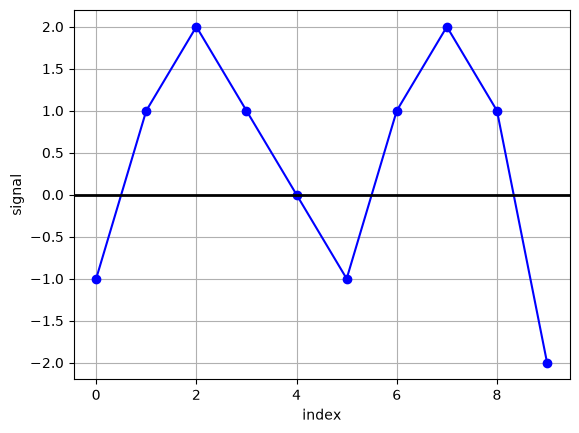

In [43]:
# Plot a simple sampled signal 

s = [-1, 1, 2, 1, 0, -1, 1, 2, 1, -2]

signal = np.array(s) # Make a numpy array from the list s
plt.plot(signal, marker='o', linestyle='-', color='b')
grid = True
plt.grid(grid)
plt.axhline(y=0, color='black', linewidth=2) # Make the 0 axis bold
plt.xlabel('index')
plt.ylabel('signal')


## 2.1 Functions to find zero crossings and to plot them

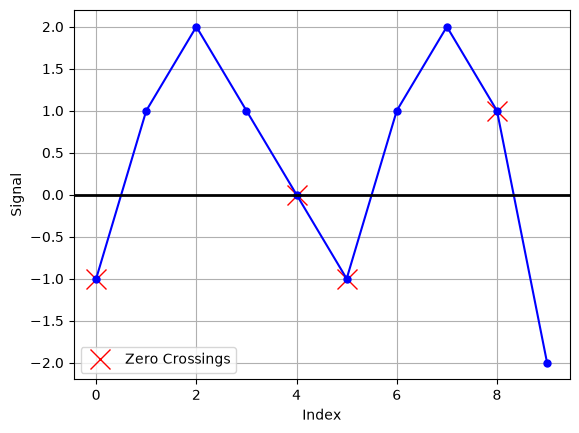

In [47]:
# Find the zero crossings in the signal

zero_crossings = np.where(np.sign(signal[:-1]) * np.sign(signal[1:]) < 0)[0]

# Zero_crossings = np.where(np.diff(np.sign(signal)) != 0)[0]

zero_values = np.where(signal == 0)[0]
zero_crossings = np.concatenate((zero_crossings, zero_values))

# Mark the zero crossings on the plot
# Plot the signal with the zero crossings marked with red circles

for i in zero_crossings:
    plt.plot(i, signal[i], 'rx', markersize=15)

plt.plot(signal, marker='o', linestyle='-', color='b', markersize=5)
grid = True
plt.grid(grid)
plt.axhline(y=0, color='black', linewidth=2)
plt.xlabel('Index')
plt.ylabel('Signal')
plt.legend(['Zero Crossings'], loc='lower left')
plt.show()



## 2.2 Find the positive and negative zero crossings

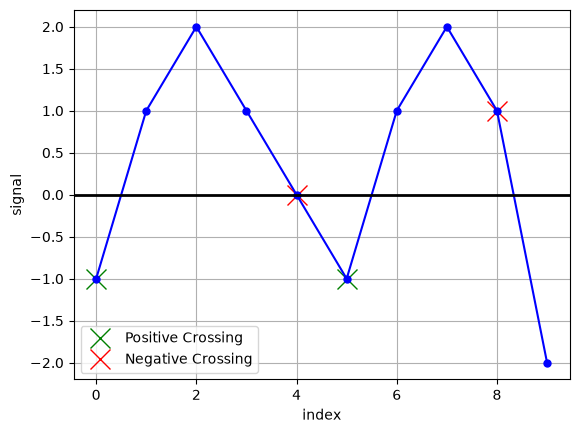

In [48]:
# Find the positive and negative zero crossings in the signal

positive_crossings = np.where((signal[:-1] < 0) & (signal[1:] > 0))[0]
negative_crossings = np.where((signal[:-1] > 0) & (signal[1:] < 0))[0]
zero_values = np.where(signal == 0)[0]

# Also mark the actual zero values in the signal
# How can we tell if this zero value is positive or negative? We can check the sign of the previous and next values in the signal. If the previous value is negative and the next value is positive, then this zero value is a positive crossing. If the previous value is positive and the next value is negative, then this zero value is a negative crossing. If both previous and next values are zero, then we can consider this zero value as a neutral crossing.

if len(zero_values) > 0:
    for i in zero_values:
        if i > 0 and i < len(signal) - 1:
            if signal[i - 1] < 0 and signal[i + 1] > 0:
                positive_crossings = np.append(positive_crossings, i)
            elif signal[i - 1] > 0 and signal[i + 1] < 0:
                negative_crossings = np.append(negative_crossings, i)
                break

# Mark the positive and negative zero crossings on the plot

for i in positive_crossings:
    plt.plot(i, signal[i], 'gx', markersize=15, label='Positive Crossing' if i == positive_crossings[0] else "")

for i in negative_crossings:
    plt.plot(i, signal[i], 'rx', markersize=15, label='Negative Crossing' if i == negative_crossings[0] else "")

plt.plot(signal, marker='o', linestyle='-', color='b', markersize=5)
grid = True
plt.grid(grid)
# make the 0 axis bold
plt.axhline(y=0, color='black', linewidth=2)
plt.xlabel('index')
plt.ylabel('signal')
legend = plt.legend(loc='lower left') 


## 2.3 Create new functions to find the local maxima and minima 

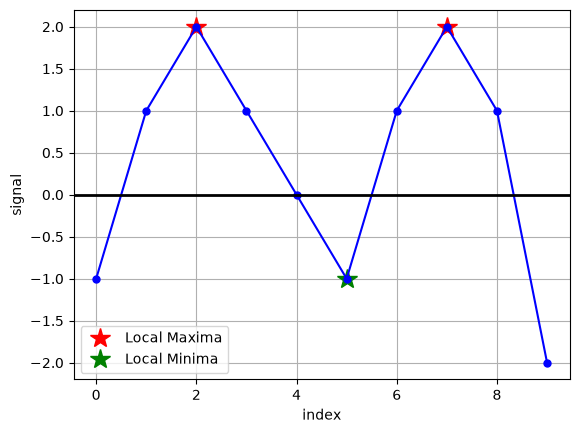

In [49]:
# Find the local maxima and minima in the signal

from scipy.signal import argrelextrema

# Find the indices of the local maxima

local_maxima = argrelextrema(signal, np.greater)

# Find the indices of the local minima

local_minima = argrelextrema(signal, np.less)

# Mark the local maxima and minima on the plot

for i in local_maxima[0]:
    plt.plot(i, signal[i], 'r*', markersize=15, label='Local Maxima' if i == local_maxima[0][0] else "")

for i in local_minima[0]:
    plt.plot(i, signal[i], 'g*', markersize=15, label='Local Minima' if i == local_minima[0][0] else "")

plt.plot(signal, marker='o', linestyle='-', color='b', markersize=5)
grid = True
plt.grid(grid)
plt.axhline(y=0, color='black', linewidth=2)
plt.xlabel('index')
plt.ylabel('signal')
legend = plt.legend(loc='lower left') 

### Function to find positive and negative zero crossings

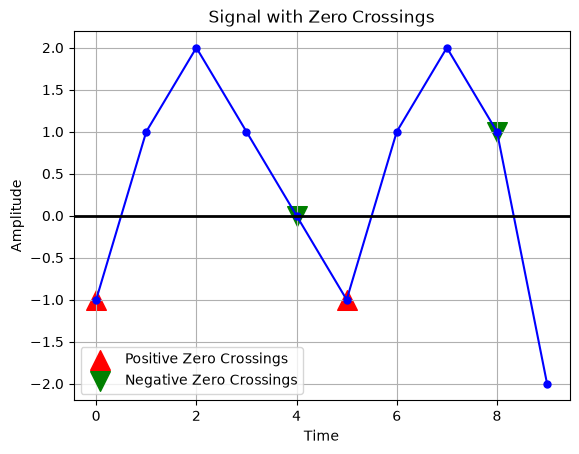

In [50]:
# Create function to find the positive and negative zero crossings in a signal and plot them. 

def plot_zero_crossings(signal):
    # Find the indices of the zero crossings
    positive_crossings = np.where((signal[:-1] < 0) & (signal[1:] > 0))[0]
    negative_crossings = np.where((signal[:-1] > 0) & (signal[1:] < 0))[0]
    zero_values = np.where(signal == 0)[0]

    if len(zero_values) > 0:
        for i in zero_values:
            if i > 0 and i < len(signal) - 1:
                if signal[i - 1] < 0 and signal[i + 1] > 0:
                    positive_crossings = np.append(positive_crossings, i)
                elif signal[i - 1] > 0 and signal[i + 1] < 0:
                    negative_crossings = np.append(negative_crossings, i)
                    break
                else:
                    # If both previous and next values are zero, we can consider this zero value as a neutral crossing.
                    pass

# Mark the positive and negative zero crossings on the plot.
    for k, i in enumerate(positive_crossings):              
        plt.scatter(i, signal[i], marker='^', label='Positive Zero Crossings' if k == 0 else "", s=200, color='red')

    for k, i in enumerate(negative_crossings): 
        plt.scatter(i, signal[i], marker='v', label='Negative Zero Crossings' if k == 0 else "", s=200, color='green')

    
plt.plot(signal, marker='o', linestyle='-', color='b', markersize=5)
signal_with_zero_crossings = plot_zero_crossings(signal)
plt.title('Signal with Zero Crossings')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.axhline(y=0, color='black', linewidth=2)
grid = True
plt.grid(grid)
plt.legend(loc='lower left')


### Function to find local minima and maxima

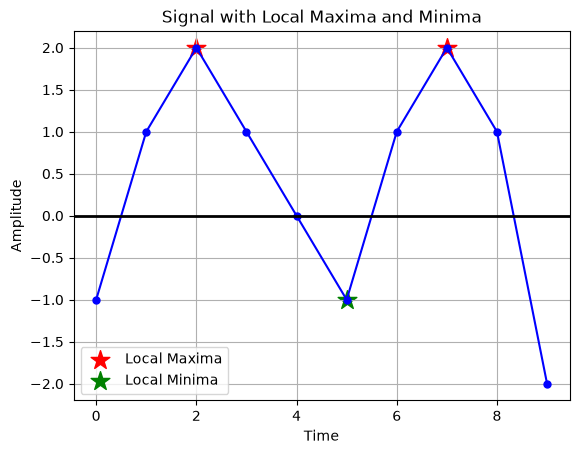

In [51]:
# Create a function to find the local maxima and minima in a signal and plot them. 

def plot_local_extrema(signal):
    # Find the indices of the local maxima
    local_maxima = argrelextrema(signal, np.greater)

    # Find the indices of the local minima
    local_minima = argrelextrema(signal, np.less)

    # Mark the local maxima and minima on the plot
    for k, i in enumerate(local_maxima[0]):
        plt.scatter(i, signal[i], marker='*', label='Local Maxima' if k == 0 else "", s=200, color='red')

    for k, i in enumerate(local_minima[0]):
        plt.scatter(i, signal[i], marker='*', label='Local Minima' if k == 0 else "", s=200, color='green')


plt.plot(signal, marker='o', linestyle='-', color='b', markersize=5)
signal_with_local_extrema = plot_local_extrema(signal)
plt.title('Signal with Local Maxima and Minima')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.axhline(y=0, color='black', linewidth=2)
grid = True
plt.grid(grid)
plt.legend(loc='lower left')

# 3. Analyze a known signal

## 3.1  Create the signal and plot it

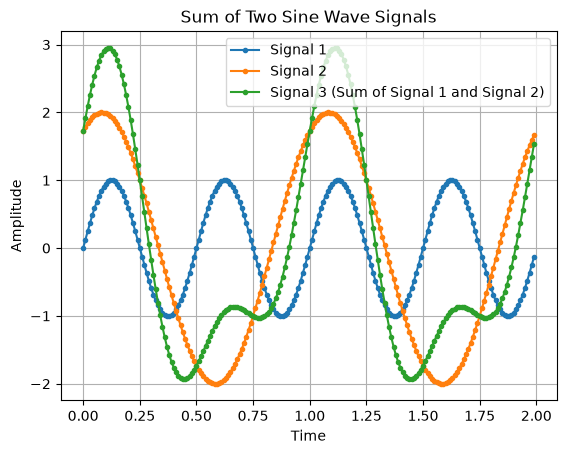

In [52]:
# Plot a signal as a sum of two sine wave signals with different frequencies and amplitudes
# Plot all three together in one plot

fs = 100 # sampling frequency (60 Hz)
duration = 2 # seconds
t = np.arange(0, duration, 1/fs)

s1 = np.sin(2 * np.pi * 2 * t) 
s2 = 2 * np.sin(2 * np.pi * 1 * t + np.pi / 3)
s3 = s1 + s2

plt.plot(t, s1, '.-', label='Signal 1')
plt.plot(t, s2, '.-', label='Signal 2')
plt.plot(t, s3, '.-', label='Signal 3 (Sum of Signal 1 and Signal 2)')
plt.title('Sum of Two Sine Wave Signals')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

## 3.2 plot the remarkable points

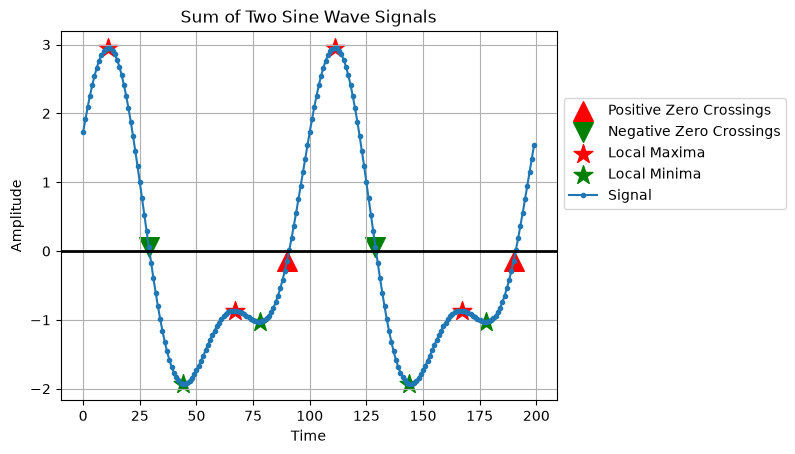

In [53]:
# Find the zero crossings and local extrema of the sum signal and plot them

signal_with_zero_crossings = plot_zero_crossings(s3)
signal_with_local_extrema = plot_local_extrema(s3)

plt.plot(s3, '.-', label='Signal')
plt.title('Sum of Two Sine Wave Signals')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.axhline(y=0, color='black', linewidth=2)
plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

## 3.3 Use the remarkable points to find the frequency of the signal

We defined a new 'find_zero_crossing' function to find the values without plotting them.

In [54]:
# Create function to find the positive and negative zero crossings in a signal and plot them

def find_zero_crossings(signal):
    # Find the indices of the zero crossings
    positive_crossings = np.where((signal[:-1] < 0) & (signal[1:] > 0))[0]
    negative_crossings = np.where((signal[:-1] > 0) & (signal[1:] < 0))[0]
    zero_values = np.where(signal == 0)[0]

    if len(zero_values) > 0:
        for i in zero_values:
            if i > 0 and i < len(signal) - 1:
                if signal[i - 1] < 0 and signal[i + 1] > 0:
                    positive_crossings = np.append(positive_crossings, i)
                elif signal[i - 1] > 0 and signal[i + 1] < 0:
                    negative_crossings = np.append(negative_crossings, i)
                    break
                else:
                    pass
    return positive_crossings, negative_crossings

We use the remarkable points to find the frequency of the signal.

**Idea:** two zero crossings with the same slope (two positive ones, or two negative ones) are separated by exactly one period.

**Method:**
1. 'find_zero_crossings' returns the indices of the positive and the negative crossings.
2. 'np.diff' gives the number of samples between two consecutive crossings of the same type.
3. Multiply by the sampling step dt to convert samples into seconds, so we get the period.
4. Average the "positive" and "negative" estimates, then frequency = 1 / period.

In [55]:
# Create function to compute the frequency of a signal from its zero crossings

def compute_frequency_from_zero_crossings(time, signal):

    """Estimate the period and frequency of a signal from its zero crossings.

    Inputs : time (1D array, seconds, uniform sampling), signal (1D array, same length)
    Output : dictionary with the spacing between crossings (samples),
             the periods (s) and the frequency (Hz)
    """
    dt = time[1] - time[0]                       # sampling step (s)

    # 1. indices of the crossings (sorted, because zero values were appended at the end)
    positive_crossings, negative_crossings = find_zero_crossings(signal)
    positive_crossings = np.sort(positive_crossings)
    negative_crossings = np.sort(negative_crossings)

    # 2. samples between two consecutive crossings of the same slope
    delta_pos = np.diff(positive_crossings)
    delta_neg = np.diff(negative_crossings)

    # 3. convert to seconds: period = mean spacing * dt
    period_pos = np.mean(delta_pos) * dt
    period_neg = np.mean(delta_neg) * dt

    # 4. final period = average of both estimates, frequency = 1 / period
    period = (period_pos + period_neg) / 2

    return {
        "delta_zero_crossing_pos (samples)": delta_pos,
        "delta_zero_crossing_neg (samples)": delta_neg,
        "signal_period_pos (s)": period_pos,
        "signal_period_neg (s)": period_neg,
        "signal_period (s)": period,
        "signal_frequency (Hz)": 1 / period,
    }


def print_frequency_info(info):
    """Print the dictionary nicely (labels right-aligned)."""
    for key, value in info.items():
        print(f"{key:>35} : {value}")

### Test on the known signal

The signal has a 1 s period (the 1 Hz sine dominates), sampled at 100 Hz, so we expect 100 samples between two crossings of the same slope, a period of 1.0 s and a frequency of 1.0 Hz.

In [56]:
# Compute the frequency of the sum signal from its zero crossings and print the results

info = compute_frequency_from_zero_crossings(t, s3)
print_frequency_info(info)

  delta_zero_crossing_pos (samples) : [100]
  delta_zero_crossing_neg (samples) : [100]
              signal_period_pos (s) : 1.0
              signal_period_neg (s) : 1.0
                  signal_period (s) : 1.0
              signal_frequency (Hz) : 1.0


**Observation:** On the clean signal, the positive and negative zero crossings are each exactly 100 samples apart, which is 100 × 0.01 s = 1.0 s at 100 Hz, so both estimates of the period agree and the frequency is 1 / 1.0 = 1.0 Hz. This matches the expected value, since the 1 Hz component dominates the signal, and it validates both our zero-crossing detection and our period computation.

# 4. Redo the analysis with a noisy signal

## 4.1 Create the noisy signal and plot it

signal_peak_to_peak_amplitude =  4.881121991355009
noise_amplitude =  0.24405609956775046


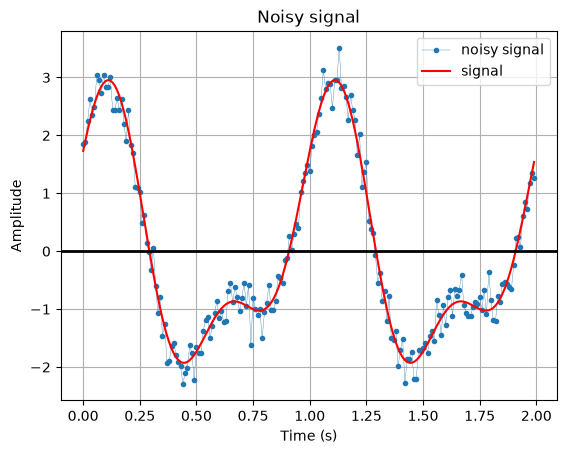

In [38]:
# Make the noise reproducible, so that everybody in the group gets the same figure.

np.random.seed(42)

# Add white noise to the signal s3, with an amplitude of 5% of the peak-to-peak amplitude of the signal

signal_peak_to_peak_amplitude = np.ptp(s3)
noise_amplitude = 0.05 * signal_peak_to_peak_amplitude
noise = np.random.normal(0, noise_amplitude, len(s3))
s_noisy = s3 + noise

# Print the peak-to-peak amplitude of the signal and the noise amplitude
print("signal_peak_to_peak_amplitude = ", signal_peak_to_peak_amplitude)
print("noise_amplitude = ", noise_amplitude)

# Plot the noisy signal and the original signal
# dots + thin line (linewidth 0.25) to see the noisy signal better

plt.plot(t, s_noisy, '.-', linewidth=0.25, label='noisy signal')
plt.plot(t, s3, color='red', label='signal')
plt.title('Noisy signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.axhline(y=0, color='black', linewidth=2)
plt.legend()
plt.grid(True)

## 4.2 Plot the remarkable points in the noisy signal

We reuse our functions 'plot_zero_crossings' and 'plot_local_extrema'. Because we will plot several signals the same way, we put the 4 plotting lines in a small function.

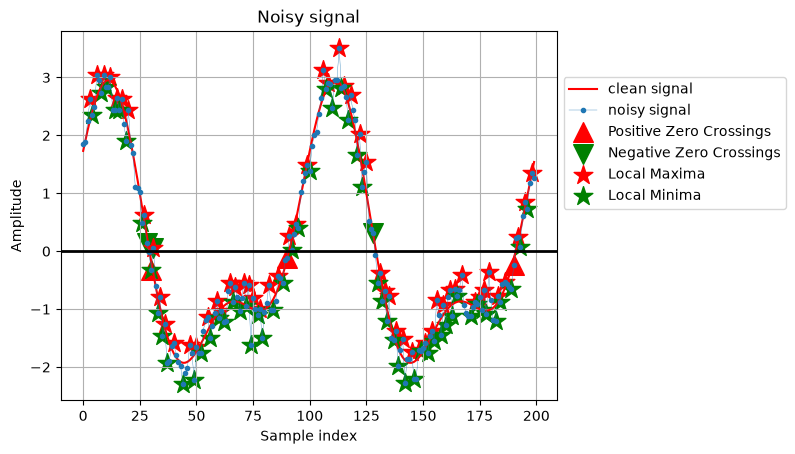

In [39]:
# Create a function to plot a signal with its zero crossings and local extrema (reuses our functions).

def display_remarkable_points(sig, title, label='signal', clean=None):
    """Plot a signal with its zero crossings and local extrema (reuses our functions).

    sig   : signal to analyse (its remarkable points are marked)
    title : plot title
    label : legend name of sig (e.g. 'noisy signal')
    clean : optional clean signal, drawn underneath for comparison
    """
    plt.figure()
    if clean is not None:
        plt.plot(clean, color='red', linewidth=1.5, label='clean signal')   # draw the clean signal underneath for comparison
    plt.plot(sig, '.-', linewidth=0.25, label=label)
    plot_zero_crossings(sig)        # adds 'Positive/Negative Zero Crossings' to the legend
    plot_local_extrema(sig)         # adds 'Local Maxima/Minima' to the legend
    plt.title(title)
    plt.xlabel('Sample index')
    plt.ylabel('Amplitude')
    plt.axhline(y=0, color='black', linewidth=2)
    plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))   # legend outside the plot
    plt.grid(True)
    plt.show()

# Display the noisy signal with its remarkable points, and the clean signal underneath for comparison
display_remarkable_points(s_noisy, 'Noisy signal', label='noisy signal', clean=s3) 

**Observation:** the noise creates many extra zero crossings and extrema, especially where the signal is close to zero (it goes back and forth across zero several times in a few samples). These show up as very small spacings between crossings, and they give a wrong period.

In [40]:
# Print the frequency information of the noisy signal

print("Analysis of the noisy signal:")
print_frequency_info(compute_frequency_from_zero_crossings(t, s_noisy))

Analysis of the noisy signal:
  delta_zero_crossing_pos (samples) : [ 60 100]
  delta_zero_crossing_neg (samples) : [ 3 97]
              signal_period_pos (s) : 0.8
              signal_period_neg (s) : 0.5
                  signal_period (s) : 0.65
              signal_frequency (Hz) : 1.5384615384615383


**Observation:** the spacings are far from 100 samples (many values of just a few samples), so the estimated frequency is far too high compared with the real 1 Hz. We need to remove the noise first.

## 4.3 Low pass filter the noisy signal 

The signal we want to measure is slow (1 to 2 Hz) while white noise contains all frequencies, including fast ones. A low-pass filter keeps the low frequencies and removes the fast ones.

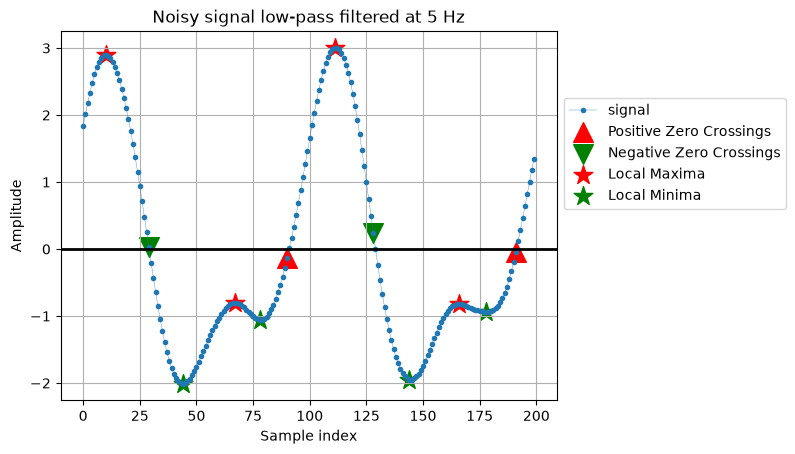

Analysis of noisy signal low pass filtered at 5 Hz:
  delta_zero_crossing_pos (samples) : [101]
  delta_zero_crossing_neg (samples) : [99]
              signal_period_pos (s) : 1.01
              signal_period_neg (s) : 0.99
                  signal_period (s) : 1.0
              signal_frequency (Hz) : 1.0


In [41]:
# We use a Butterworth filter (butter) applied with filtfilt, which filters forward then backward, so the filtered signal is not delayed (zero phase) and the zero crossings stay at the right place.

from scipy.signal import butter, filtfilt

# Cutoff = 5 Hz: above the signal frequencies (1 and 2 Hz), so the signal is kept, but low enough to remove most of the noise. 

cutoff = 5
b, a = butter(4, cutoff / (fs / 2), btype='low') # filter coefficients (order 4)
s_filtered = filtfilt(b, a, s_noisy) # apply the filter without delay

# Display the filtered signal with its remarkable points and print the frequency information of the filtered signal

display_remarkable_points(s_filtered, 'Noisy signal low-pass filtered at 5 Hz')

print("Analysis of noisy signal low pass filtered at 5 Hz:")
print_frequency_info(compute_frequency_from_zero_crossings(t, s_filtered))

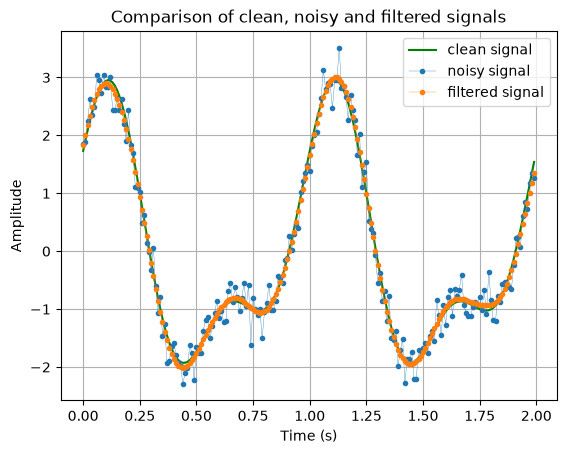

In [42]:
# Plot the clean, noisy and filtered signals together for comparison

plt.figure()
plt.plot(t, s3, color='green', linewidth=1.5, label='clean signal')
plt.plot(t, s_noisy, '.-', linewidth=0.25, label='noisy signal')
plt.plot(t, s_filtered, '.-', linewidth=0.25, label='filtered signal')
plt.title('Comparison of clean, noisy and filtered signals')   
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

**Observation:** after filtering, the extra crossings disappeared. The spacings are close to 100 samples again and the frequency is close to 1 Hz (small differences come from the remaining noise). We recovered the frequency of the signal even though the raw noisy signal gave a wrong result.